Recently I was looking at a set of calculations that included an operation to interpolate between two droplet size distributions for the plume that is emitted from cooling towers. I wanted to unpack that and think about why I might want to do it differently.

Cooling tower plumes are not merely clouds of water droplets, they are also an important source of VOC emissions and salts which are deposited in the shadow of the towers. These salts can also form fine particulates, which are an important air pollutant. This occurs when the droplets in the plume evaporate away leaving behind the (formerly) dissolved solids as small diameter crystals. The calculations I was looking at were for estimating the fraction of droplets in the plume which form fine particulates (PM10), which is related to the droplet size distribution of the cloud[@reisman-2002].

Cooling tower operators rarely have a nice characterization of the droplets in the plume. The goal is to estimate the droplet size distribution using known operating parameters, such as the drift rate. Environment and Climate Change Canada (ECCC) has produced a calculation aid[@eccc-2024] for this purpose, and that is what I would like to critique here.

In [1]:
#| echo: false
#| output: false
using CairoMakie, Latexify, DataFrames, CSV, Markdown, Handcalcs

post_theme = merge(theme_latexfonts(), Theme(palette = (color = to_colormap(:seaborn_muted6),)));

The ECCC Model
--------------

The ECCC model starts with two known droplet size distributions, in the form of cumulative mass distributions. These two distributions are for towers with substantially different drift rates, and the task is to estimate the droplet size distribution for a new drift rate in between. The tool does this by lining up the two tables of frequencies and averaging them. Both the fraction less than the given diameter as well as the diameters, because the two datasets are not binned in the same way.

The first operation, averaging the frequencies to find a mid-point distribution, makes some sense for a mixture model of droplet size (more on that later) but that second operation of averaging the bins strikes me as unjustified.

We can frame this averaging procedure as an interpolation between two drift rates $W_1$ and $W_2$ using an interpolation index $t$

$$ t = { {W_t - W_1} \over {W_2 - W_1} } $$

which ranges from zero to one. In this case the ECCC tool is interpolating to $t = 0.5$ and $W_t = 0.0052\%$

::: {.callout-note}
The arithmetic average is equivalent to a linear interpolation at the midpoint.

$$ y_{mid} = { {y_2 - y_1} \over {x_2 - x_1} } \left( x_{mid} - x_1 \right) + y_1 $$

$$ y_{mid} = { {y_2 - y_1} \over {x_2 - x_1} } \left( \frac{x_2 + x_1}{2} - x_1 \right) + y_1 $$

$$ y_{mid} = { {y_2 - y_1} \over {x_2 - x_1} } \left( \frac{x_2 - x_1}{2} \right) + y_1 $$

$$ y_{mid} = { {y_2 - y_1} \over 2 } + y_1 $$

$$ y_{mid} = { {y_2 + y_1} \over 2 } $$

:::

Before we dive into doing any math, below are the two datasets we will be working with, loaded into `DataFrame`s and scaled.

In [2]:
#| output: false
# Drift Data from Old Wood Herringbone Mist Eliminators
# W = 0.01%
herringbone = CSV.read(IOBuffer("""
d	F
0	0.00
15	0.15
25	0.29
35	0.99
45	2.22
55	3.79
65	5.54
80	9.25
100	13.52
120	18.15
140	22.97
165	32.07
195	42.56
225	53.43
255	63.24
285	71.38
325	80.88
375	87.36
425	90.89
475	94.04
550	97.54
650	99.52
750	99.52
850	99.52
950	100.00
"""), DataFrame; delim="	", types=[Float64, Float64], header=true);

herringbone.F .= herringbone.F ./ 100

25-element Vector{Float64}:
 0.0
 0.0015
 0.0029
 0.009899999999999999
 0.0222
 0.0379
 0.0554
 0.0925
 0.1352
 0.1815
 0.2297
 0.3207
 0.42560000000000003
 0.5343
 0.6324000000000001
 0.7138
 0.8088
 0.8736
 0.9089
 0.9404
 0.9754
 0.9952
 0.9952
 0.9952
 1.0

In [3]:
#| output: false
# Drift Data from New Cellular Drift Eliminators
# W = 0.0003%
cellular = CSV.read(IOBuffer("""
d	F
0	0.00
10	0.00
20	0.20
30	0.23
40	0.51
50	1.82
60	5.70
70	21.35
90	49.81
110	70.51
130	82.02
150	88.01
180	91.03
210	92.47
240	94.09
270	94.69
300	96.29
350	97.01
400	98.34
450	99.07
500	99.07
600	100.00
"""), DataFrame; delim="	", types=[Float64, Float64], header=true);

cellular.F .= cellular.F ./ 100

22-element Vector{Float64}:
 0.0
 0.0
 0.002
 0.0023
 0.0051
 0.0182
 0.057
 0.21350000000000002
 0.49810000000000004
 0.7051000000000001
 0.8201999999999999
 0.8801000000000001
 0.9103
 0.9247
 0.9409000000000001
 0.9469
 0.9629000000000001
 0.9701000000000001
 0.9834
 0.9906999999999999
 0.9906999999999999
 1.0

The method presented in the ECCC calculator is equivalent to the following

In [4]:
#| output: false
t = 0.5

ECCC = DataFrame()
ECCC.d = (1-t)*herringbone.d[1:length(cellular.d)] .+ t*cellular.d
ECCC.F = (1-t)*herringbone.F[1:length(cellular.F)] .+ t*cellular.F

22-element Vector{Float64}:
 0.0
 0.00075
 0.00245
 0.0060999999999999995
 0.01365
 0.028050000000000002
 0.0562
 0.15300000000000002
 0.31665
 0.4433
 0.5249499999999999
 0.6004
 0.66795
 0.7295
 0.7866500000000001
 0.8303499999999999
 0.88585
 0.9218500000000001
 0.94615
 0.9655499999999999
 0.98305
 0.9976

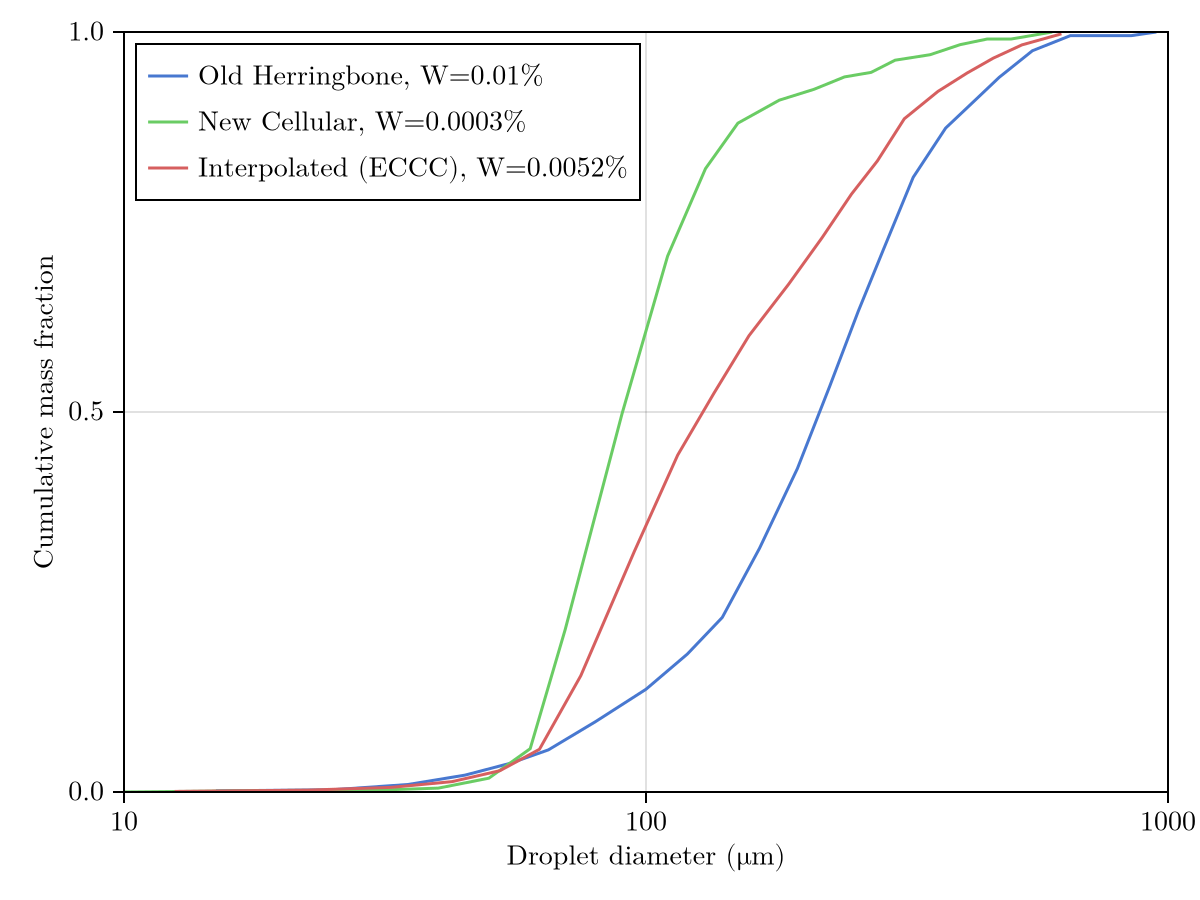

In [5]:
#| echo: false
#| label: fig-eccc-model
#| fig-cap: "The two measured droplet size distributions and the distribution interpolated by the ECCC model."
with_theme(post_theme) do
    f = Figure(figurepadding=0)
    ax = Axis(f[1, 1],
        xlabel = "Droplet diameter (μm)",
        xscale = log10,
        xticks = [10, 100, 1000],
        ylabel = "Cumulative mass fraction",
        limits = ((10,1000),(0,1)),
        #aspect = DataAspect()
    )
    lines!(ax, herringbone.d, herringbone.F, label="Old Herringbone, W=0.01%")
    lines!(ax, cellular.d, cellular.F, label="New Cellular, W=0.0003%")
    lines!(ax, ECCC.d, ECCC.F, label="Interpolated (ECCC), W=$( round((1-t)*0.01 + t*0.0003, digits=4))%")
    axislegend(position=:lt)
    f
end

In [6]:
#| echo: false
let

display(Markdown.parse("""
        It is not immediately clear from the plot, but the interpolated cdf ends before all of the mass has been accounted for, ending at $(ECCC.F[end]*100)%
        """))

end

It is not immediately clear from the plot, but the interpolated cdf ends before all of the mass has been accounted for, ending at 99.76%


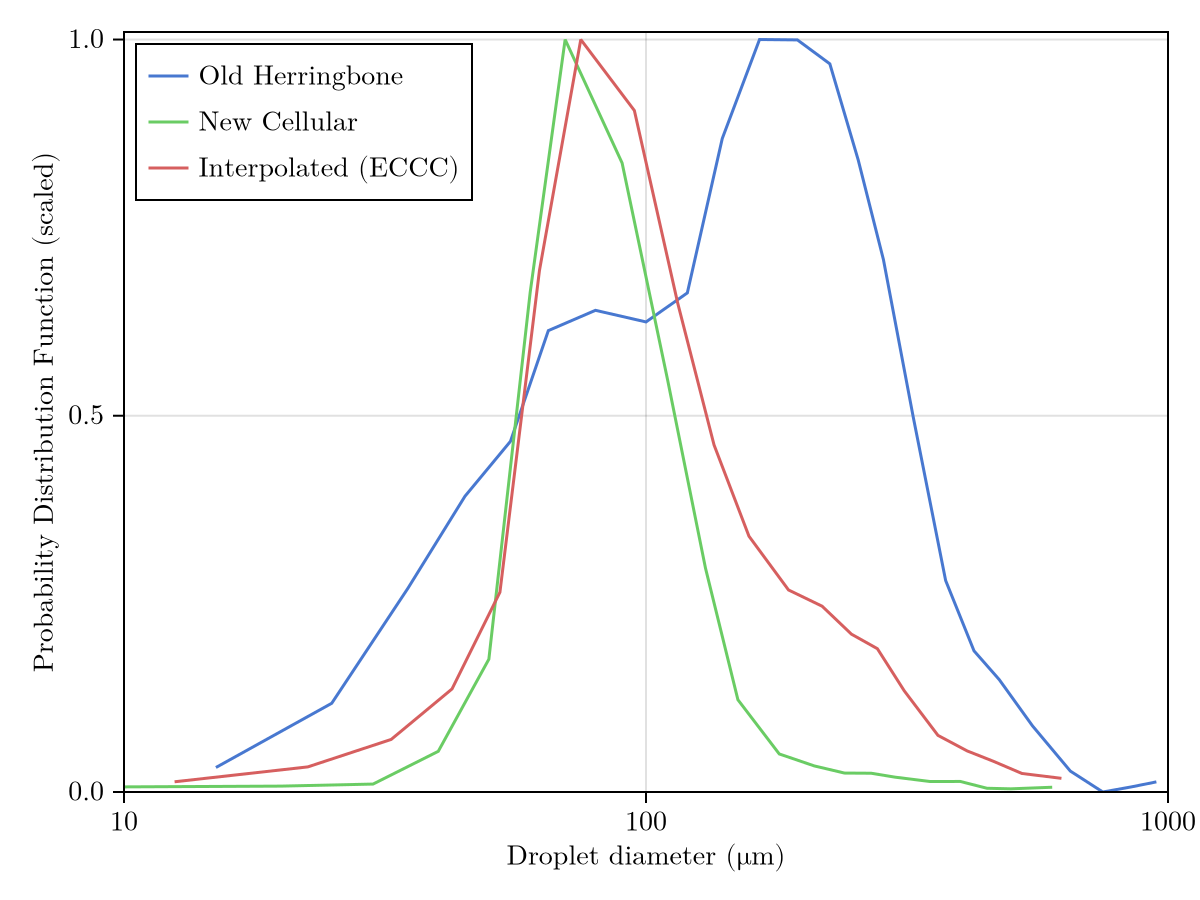

In [7]:
#| echo: false
#| label: fig-eccc-model-pdf
#| fig-cap: "The probability distribution function, scaled such that the max value is 1."
function 𝒻(df)
    f_mid = (df.F[3:end] .- df.F[1:end-2]) ./ ( df.d[3:end] .- df.d[1:end-2] )
    f_fwd = (df.F[2] - df.F[1]) / (df.d[2] - df.d[1])
    f_rvs = (df.F[end] - df.F[end-1]) / (df.d[end] - df.d[end-1])
    return vcat(f_fwd,f_mid,f_rvs)
end

herringbone.f = 𝒻(herringbone)
cellular.f = 𝒻(cellular)
ECCC.f = 𝒻(ECCC)

with_theme(post_theme) do
    f = Figure(figurepadding=0)
    ax = Axis(f[1, 1],
        xlabel = "Droplet diameter (μm)",
        xscale = log10,
        xticks = [10, 100, 1000],
        ylabel = "Probability Distribution Function (scaled)",
        limits = ((10,1000),(0,1.01)),
        #aspect = DataAspect()
    )
    lines!(ax, herringbone.d, herringbone.f ./ maximum(herringbone.f), label="Old Herringbone")
    lines!(ax, cellular.d, cellular.f ./ maximum(cellular.f), label="New Cellular")
    lines!(ax, ECCC.d, ECCC.f ./ maximum(ECCC.f), label="Interpolated (ECCC)")
    axislegend(position=:lt)
    f
end

The interpolated cumulative distribution function certainly looks plausible. It lies in between the two bracketing cdfs and has a similar looking vibe to it. The corresponding probability distribution functions ([@fig-eccc-model-pdf]) are suggestive of the idea that there might be two underlying distributions -- the Old Herringbone dataset looks like it has two humps. They also all look plausibly like log normal distributions.

A Mixture Model
---------------

One rationale for directly interpolating the cdfs, such as the ECCC model, is when there are two underlying processes generating droplets. If the final plume is best thought of as a mixture of droplets from these two processes then a reasonable model for the plume cdf might be:

$$ F_t(d) = (1 - t)F_1(d) + tF_2(d) $$

Where $t$ is some index related to the proportion of droplets from process 1 versus process 2 -- something we're assuming is a function of drift rate in this case. It is not necessary for $F_1$ and $F_2$ to represent "pure" process 1 and "pure" process 2 either, just that they bracket the value we want to interpolate.

::: {#fig-mixture-model-block-diagram}

![](cooling-tower-mixed-model.png)

A model for cooling tower plume generation, two sub-processes generate mists of air and water which are combined prior to being emitted from the tower.
:::

I would expect that if this were the case for a cooling tower the droplet size distribution should be bimodal. Which certainly looks to be the case for the Old Wood Herringbone dataset. I think you could make the argument that better mist eliminators more efficiently remove the peak at the larger droplet sizes, leaving a distribution mostly centered around the smaller droplet sizes, justifying what we see with the New Cellular dataset. Buttressing the argument for a mixture, the peak at the smaller diameter for the Old Wood Herringbone dataset is roughly where the peak of the New Cellular dataset sits. Which waggles its eyebrows suggestively at the idea that a mixture model makes sense.

Having fallen for the siren song of a mixture model, how would I go about it? Double interpolation: For a given diameter of interest, $d$, first interpolate the value of the cdf at the bracketing distributions:

$$ F_1(d) = { {F_{1,i+1} - F_{1,i}} \over {d_{i+1} - d_i } } \left( d - d_i \right) + F_{1,i} $$

$$ F_2(d) = { {F_{2,k+1} - F_{2,k}} \over {d_{k+1} - d_k } } \left( d - d_k \right) + F_{2,k} $$

Where $d$ falls between $d_i$ and $d_{i+1}$ in the first data set and between $d_k$ and $d_{k+1}$ in the second data set.

The final value is then given by the interpolation:

$$ F_t(d) = (1 - t)F_1(d) + t F_2(d) $$

In [8]:
using Interpolations: linear_interpolation, Flat

In [9]:
#| output: false
F₁ = linear_interpolation(herringbone.d, herringbone.F;
                          extrapolation_bc = Flat())

F₂ = linear_interpolation(cellular.d,cellular.F;      # <1>
                          extrapolation_bc = Flat())  # <2>

Fₜ(d; t=0.5) = (1-t)*F₁(d) + t*F₂(d)                  # <3>

Fₜ (generic function with 1 method)

1. Linear interpolation of the experimental data using `Interpolations.jl`
2. Assume the cdfs are constant at the ends, so $F(d) = F_{max} = 1.0$ when $d>d_{max}$
3. Interpolate between $F_1$ and $F_2$ to arrive at the final cdf.

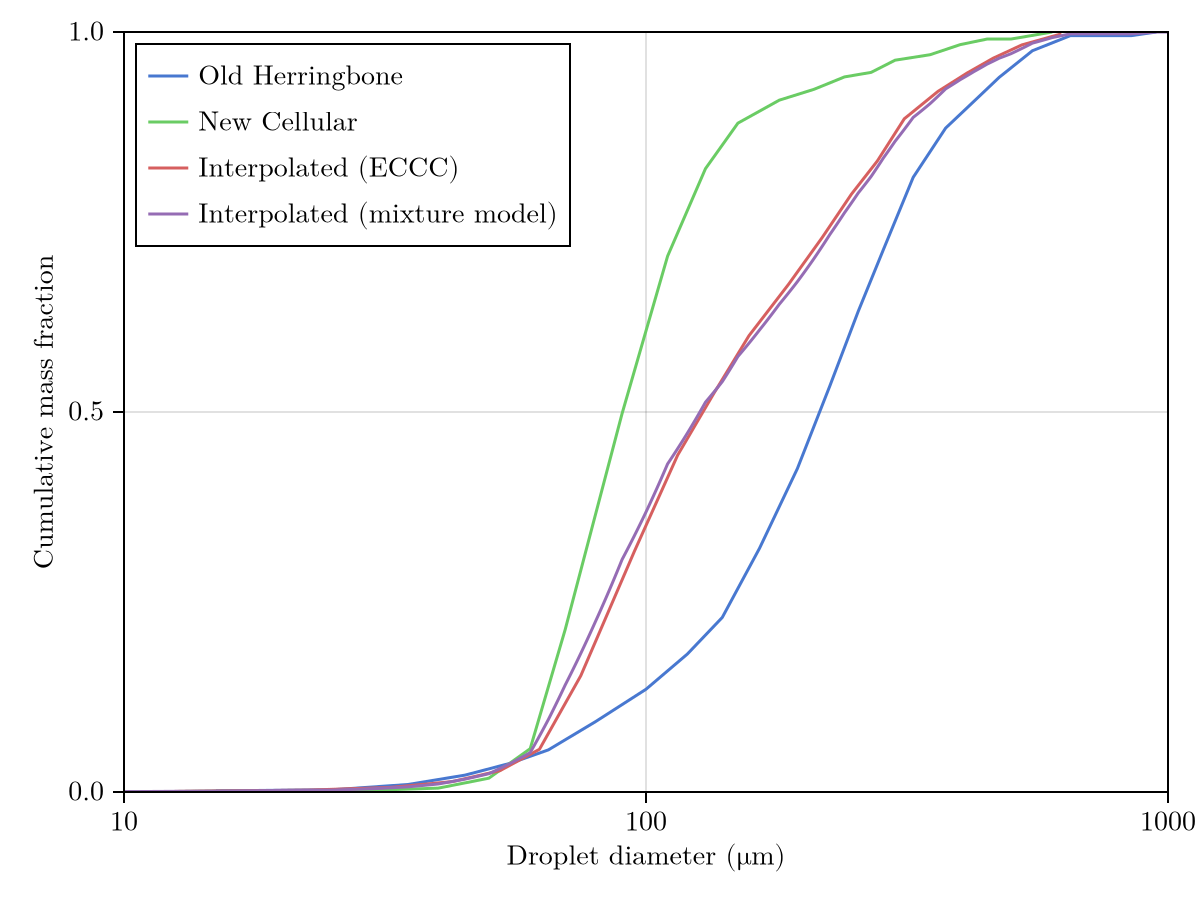

In [10]:
#| echo: false
#| label: fig-mixture-model
#| fig-cap: "The two measured droplet size distributions, the interpolated by the ECCC model, and the mixture model."
with_theme(post_theme) do
    f = Figure(figurepadding=0)
    ax = Axis(f[1, 1],
        xlabel = "Droplet diameter (μm)",
        xscale = log10,
        xticks = [10, 100, 1000],
        ylabel = "Cumulative mass fraction",
        limits = ((10,1000),(0,1)),
        #aspect = DataAspect()
    )
    lines!(ax, herringbone.d, herringbone.F, label="Old Herringbone")
    lines!(ax, cellular.d, cellular.F, label="New Cellular")
    lines!(ax, ECCC.d, ECCC.F, label="Interpolated (ECCC)")
    
    ds = 10.0:1.0:1000.0
    lines!(ax, ds, Fₜ.(ds), label="Interpolated (mixture model)")
    axislegend(position=:lt)
    f
end

Linear interpolation for $F_1$ and $F_2$ is the simplest case, one could use some higher order interpolation to give a smoother cdf. Some care does need to be taken to ensure the final cdf is normalized, but if both $F_1$ and $F_2$ are appropriately bracketed -- e.g. start at 0 and end at 1 -- then this will just work out on its own.

The advantage of this approach is that it is simple to implement, makes few assumptions about the underlying distribution, and can be extended easily to include additional datasets for intermediate drift rates. In this particular case the two datasets were binned in almost the same way so the ECCC approach worked out pretty closely, but if the bins were quite different that would not have been the case and I think it would be hard to justify the simple averaging procedure.

The disadvantage, I think, is theoretical: this is really implicitly assuming a mixture of two underlying droplet distributions and adjusting how much of each one ends up in the final distribution. We only have two sets of data and only one of them is *maybe* consistent with that assumption, this may simply be a mirage.

A Parametric Model
------------------

A different approach, and what I would have suggested prior to looking at the ECCC model and the data, would be to fit a parametric model to the data and interpolate on the parameters. For droplet size distributions from jets and sprays it is fairly common to assume a log normal distribution and use a correlation that relates the mean droplet size to some process variables. It is not unreasonable to expect the droplet size distribution from a cooling tower to be approximately log normal and the parameters of the distribution to be a function of the tower geometry and operating parameters.

I'm being a little loose with terminology, by "fitting" a log-normal distribution to this binned data what I really mean is finding the parameters $\mu$ and $\sigma$ which minimize the [K-L divergence](https://en.wikipedia.org/wiki/Kullback%E2%80%93Leibler_divergence) between the observed cdf and that of a log-normal distribution (with parameters $\mu$ and $\sigma$ obviously).

$$ D_{KL} = \sum_i \left( F_{i+1} - F_{i} \right) \log \left( {F_{i+1} - F_{i}} \over { LN\left( d_{i+1}; \mu, \sigma \right) - LN\left( d_{i} ; \mu, \sigma \right) }\right) $$

Where $LN\left( x ; \mu, \sigma \right)$ is the cdf for the [log-normal distribution](https://en.wikipedia.org/wiki/Log-normal_distribution). Expanding the log gives

$$ D_{KL} = \sum_i \left( F_{i+1} - F_{i} \right) \log \left( {F_{i+1} - F_{i}} \right) - \sum_i \left( F_{i+1} - F_{i} \right) \log \left( LN\left( d_{i+1}; \mu, \sigma \right) - LN\left( d_{i} ; \mu, \sigma \right) \right) $$

The entire expression $\sum_i \left( F_{i+1} - F_{i} \right) \log \left( {F_{i+1} - F_{i}} \right)$ is a constant with respect to $\mu$ and $\sigma$ so minimizing the KL divergence ultimately amounts to maximizing 

$$ \mathscr{l} = \sum_i \left( F_{i+1} - F_{i} \right) \log \left( LN\left( d_{i+1}; \mu, \sigma \right) - LN\left( d_{i} ; \mu, \sigma \right) \right) $$

which is just maximizing the log-likelihood (something you may have expected).

A useful starting approximation for $\mu$ and $\sigma$ is

$$ \mu_0 = \frac{1}{2} \sum_i \left( F_{i+1} - F_{i} \right) \left( \log d_{i+1} + \log d_{i} \right) $$

$$ \sigma_0^2 = \frac{1}{4} \sum_i \left( F_{i+1} - F_{i} \right) \left( \log d_{i+1} + \log d_{i} \right)^2 - \mu_0^2$$

These will not always be great approximations, especially when there are few bins, but they are useful starting points. Probably one could work through setting $\frac{\partial \mathscr{l}}{\partial \mu} = 0$ and $\frac{\partial \mathscr{l}}{\partial \sigma} = 0$ and solving for $\mu$ and $\sigma$ that way. It is just as easier for the lazy engineer to pop everything into `Optim.jl` and have it do all the work.

In [11]:
using Optim
using Distributions: LogNormal, cdf, pdf

In [12]:
#| output: false
function fit_lognormal(ds, Fs)          
    a, b = ds[1:end-1], ds[2:end]

    function log_likely(params)    # <1>
        μ, σ = params
        LN = LogNormal(μ,σ)
        return -sum( ( Fs[2:end] .- Fs[1:end-1] ) .* log.( cdf(LN, b ) .- cdf(LN, a ) ) )
    end

    mids = 0.5*( log.(b) .+ log.(a) ); mids = mids[2:end] # <2>
    μ₀ = sum( ( Fs[3:end] .- Fs[2:end-1] ) .* mids ) # <3>
    σ₀² = sum( ( Fs[3:end] .- Fs[2:end-1] ) .* ( mids.^2) ) - μ₀^2 # <3>
    
    res = optimize(log_likely, [μ₀, √(σ₀²)], NelderMead()) # <4>
    μ,σ = Optim.minimizer(res)
    return μ, σ, res
end

fit_lognormal (generic function with 1 method)

1. Define the (negative) log likelihood, $\mathscr{l}$
2. The first bin starts at $\log d = \log 0 = -\infty$, so it has to be dropped when estimating $\mu_0$ and $\sigma_0$
3. Calculate the initial guess for $\mu$ and $\sigma$
4. Find the set of parameters which minimize the negative log likelihood, equivalent to maximizing the log likelihood

In [13]:
#| output: false
μh, σh, resh = fit_lognormal(herringbone.d, herringbone.F)
μc, σc, resc = fit_lognormal(cellular.d, cellular.F)

(4.583966210052922, 0.4561029961830967,  * Status: success

 * Candidate solution
    Final objective value:     2.302940e+00

 * Found with
    Algorithm:     Nelder-Mead

 * Convergence measures
    √(Σ(yᵢ-ȳ)²)/n ≤ 1.0e-08

 * Work counters
    Seconds run:   0  (vs limit Inf)
    Iterations:    27
    f(x) calls:    55
)

After finding the log-normal fit to the two datasets, we then interpolate the parameters for the new log-normal distribution using

$$ \mu_t = (1-t) \mu_h + t \mu_c $$

$$ \sigma^2_t = (1-t) \sigma_h^2 + t \sigma_c^2 $$

Below I have provided a helper function that gives us a new `LogNormal` distribution as a function of $t$ (and we can use the functions built into `Distributions.jl` to retrieve whatever we like)

In [14]:
#| output: false
function LNₜ(t)
    μₜ = (1-t)*μh + t*μc
    σₜ = √( (1-t)*σh^2 + t*σc^2 )
    return LogNormal(μₜ,σₜ)
end

LNₜ (generic function with 1 method)

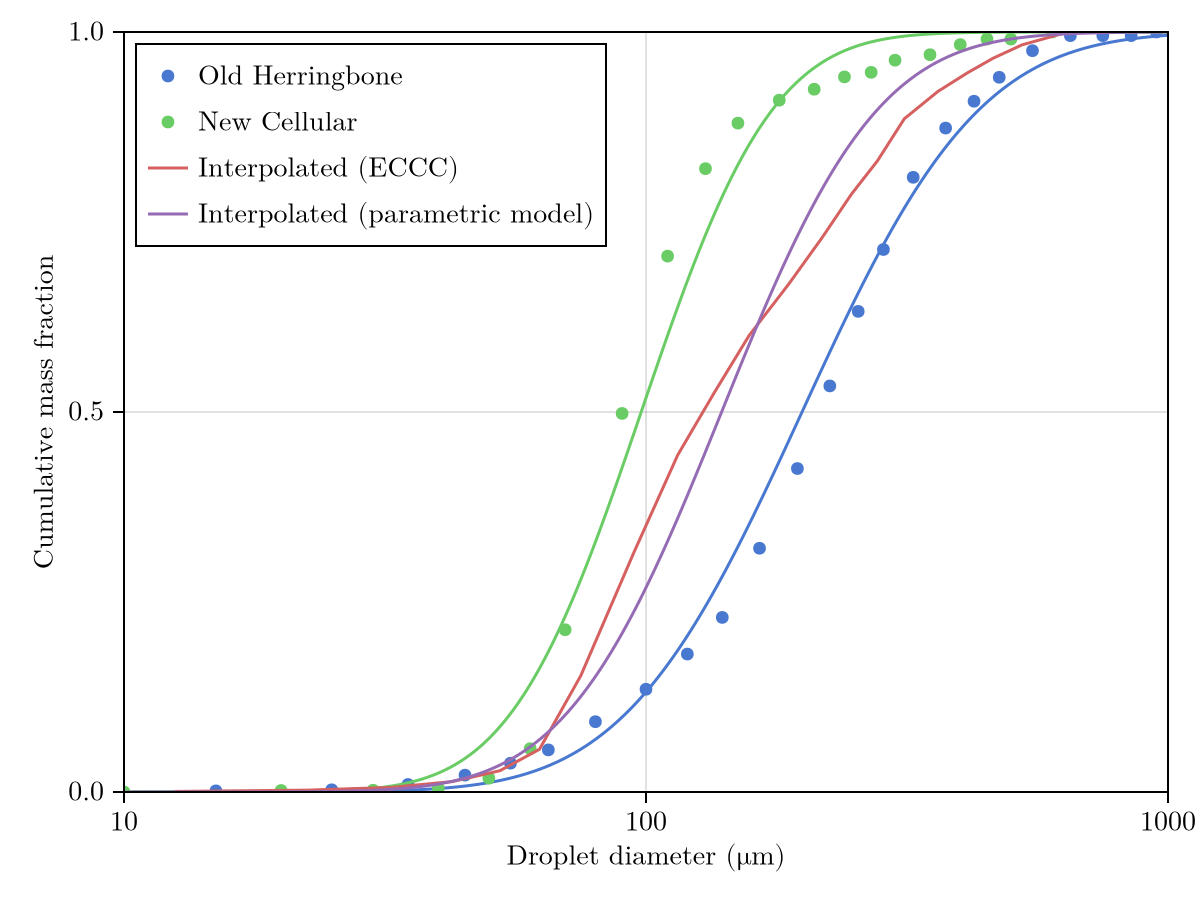

In [15]:
#| echo: false
#| label: fig-parametric-model
#| fig-cap: "The two measured droplet size distributions, with log-normal fits, the ECCC model, and an interpolated log-normal distribution."
with_theme(post_theme) do
    f = Figure(figurepadding=0)
    ax = Axis(f[1, 1],
        xlabel = "Droplet diameter (μm)",
        xscale = log10,
        xticks = [10, 100, 1000],
        ylabel = "Cumulative mass fraction",
        limits = ((10,1000),(0,1)),
        #aspect = DataAspect()
    )
    
    ds = 10.0:1.0:1000.0
    scatter!(ax, herringbone.d, herringbone.F, label="Old Herringbone")
    lines!(ax, ds, cdf(LogNormal(μh,σh), ds))
    
    scatter!(ax, cellular.d, cellular.F, label="New Cellular")
    lines!(ax, ds, cdf(LogNormal(μc,σc), ds))

    lines!(ax, ECCC.d, ECCC.F, label="Interpolated (ECCC)")
    lines!(ax, ds, cdf(LNₜ(t), ds), label="Interpolated (parametric model)")
    axislegend(position=:lt)
    f
end

This approach has the feature of preserving the overall shape of the droplet size distribution. If we are assuming the distribution should always be log-normal, this results in that. We also can take advantage of the well known pdf and cdf of the log-normal distribution to calculate whatever additional values we need for an analysis of the droplets. For example, in the original tool the ultimate goal is to calculate the mass fraction of the plume with diameters below some critical diameter, which comes directly from the cdf.

Looking at the plot of the observed and fitted cdfs we can almost convince ourselves of the opposite of what we concluded from looking at the pdfs. The Old Herringbone dataset looks like a better fit to a log-normal model than the New Cellular dataset. Maybe the two humps on the cdf was just an artifact of how the data was binned. This leads to the sort of impasse that comes with only having two sets of data for this. *Should* we be assuming the droplets are log-normal? It's a pretty *normal* assumption to make. On the other-hand assuming the mixture model, and directly interpolating the cdf, is also making some implicit claims on the underlying process that generates the droplets that maybe aren't true?

Wandering off
-------------

There's nothing stopping us from combining these two ideas, doubling down on the idea that a plume droplet size distribution should be bimodal *and also* that the underlying processes generating this produce log-normal droplet size distributions. We can combine the two sets of observed cdfs, and find the parameters that minimize the KL divergence for the pdf, $g(d)$

$$ g(d) = (1 - \xi) \mathscr{f}_{LN}\left( d; \mu_1, \sigma_1 \right) + \xi \mathscr{f}_{LN}\left( d; \mu_2, \sigma_2 \right) $$

where $\mathscr{f}_{LN}$ is the pdf of the log-normal distribution and $\xi$ controls the weighting between droplet distribution 1 and droplet distibution 2. Integrating to the cdf gives

$$ G(d) = (1 - \xi) \int_{0}^{d} \mathscr{f}_{LN}\left( x; \mu_1, \sigma_1 \right) dx + \xi \int_{0}^{d} \mathscr{f}_{LN}\left( x; \mu_2, \sigma_2 \right) dx $$

$$ G(d) = (1 - \xi) LN \left( d; \mu_1, \sigma_1 \right) + \xi LN \left( d; \mu_2, \sigma_2 \right) $$

In this model we want both the Old Herringbone and New Cellular distributions to share the parameters $\mu_1$, $\sigma_1$, $\mu_2$, and $\sigma_2$, they will only differ in $\xi$. Putting this in terms of KL divergence, we want to find the parameters $\mu_1$, $\sigma_1$, $\mu_2$, $\sigma_2$, $\xi_h$, $\xi_c$ which minimize

$$ D_{KL} = \sum_{i \in \mathrm{herringbone}} \left( F_{i+1} - F_{i} \right) \log \left( {F_{i+1} - F_{i}} \over { G(d_{i+1}; \xi_h, \dots) - G(d_{i}; \xi_h, \dots) }\right) + \sum_{j \in \mathrm{cellular}} \left( F_{j+1} - F_{j} \right) \log \left( {F_{j+1} - F_{j}} \over { G(d_{j+1}; \xi_c, \dots) - G(d_{j}; \xi_c, \dots) }\right) $$

Following the same logic as before, this is equivalent to maximizing the log-likelihood given by

$$ \mathscr{l} = \sum_{i \in \mathrm{herringbone}} \left( F_{i+1} - F_{i} \right) \log \left( { G(d_{i+1}; \xi_h, \dots) - G(d_{i}; \xi_h, \dots) }\right) + \sum_{j \in \mathrm{cellular}} \left( F_{j+1} - F_{j} \right) \log \left( { G(d_{j+1}; \xi_c, \dots) - G(d_{j}; \xi_c, \dots) }\right) $$

To make my life simpler I am going write some helper functions. If this was going to be used in a more fulsome analysis or calculation tool, building a proper distribution consistent with `Distributions.jl` would be worthwhile. I'm just going to cobble together a struct and overload some functions to get a minimum viable distribution for what I need right now.

In [16]:
struct MixtureModel{D1,D2,F}
    d1::D1
    d2::D2
    ξ::F
end

In [17]:
#| output: false
# a mixture model of two arbitrary distributions dist1 and dist2
import Distributions.cdf

cdf(m::MixtureModel, x::Real) = (1-m.ξ)*cdf(m.d1,x) + m.ξ*cdf(m.d2,x)

# this is a really lazy way of doing this since I know I'm only using vectors
cdf(m::MixtureModel, v::AbstractArray{<:Real}) = [ cdf(m,x) for x in v ]

cdf (generic function with 85 methods)

Then the log-likelihood for a given dataframe, with columns `d` and `F`

In [18]:
#| output: false
function log_likelihood_dataframe(df, mm::MixtureModel)
    Ga = cdf(mm, df.d[1:end-1])
    Gb = cdf(mm, df.d[2:end])
    return sum( (df.F[2:end] .- df.F[1:end-1]) .* log.( Gb .- Ga ) )
end

log_likelihood_dataframe (generic function with 1 method)

Finally a function which fits the mixture cdf to two dataframes `dfa` and `dfb` -- this could be written more generically so that any number of data sets could be included fairly easily, but I only have two so that's good enough for now.

In [19]:
#| output: false
function fit_parametric_mixture(dfa, dfb;  ξa=0.5, ξb=0.5, 
                                           μ₁=μh, σ₁=σh, μ₂=μc, σ₂=σc)
    function log_likely(params)
        ξa, ξb, μ₁, σ₁, μ₂, σ₂ = params
        dist1 = LogNormal(μ₁, σ₁)
        dist2 = LogNormal(μ₂, σ₂)
        la = log_likelihood_dataframe(dfa, MixtureModel(dist1,dist2,ξa))
        lb = log_likelihood_dataframe(dfb, MixtureModel(dist1,dist2,ξb))
        return -(la + lb) # <1>
    end
    
    lower = zeros(6)                       # <2>
    upper = [1.0, 1.0, Inf, Inf, Inf, Inf] # <2>
    initial = [ξa, ξb, μ₁, σ₁, μ₂, σ₂]     # <3>
    res = optimize(log_likely, lower, upper, initial, 
                   Fminbox( NelderMead() )) # <4>
    return res
end

fit_parametric_mixture (generic function with 1 method)

1. Again this is the *negative* log likelihood, which is being minimized
2. In this case the $\xi$ must be strictly between zero and one
3. The initial guess is derived from the log normal fits performed earlier
4. The optimization algorithm is the same, but with box constraints

With all of this in place we can easily fit the parametric mixture model to the two datasets.

In [20]:
res = fit_parametric_mixture(herringbone, cellular)

 * Status: success

 * Candidate solution
    Final objective value:     4.997943e+00

 * Found with
    Algorithm:     Fminbox with Nelder-Mead

 * Convergence measures
    |x - x'|               = 0.00e+00 ≤ 0.0e+00
    |x - x'|/|x'|          = 0.00e+00 ≤ 0.0e+00
    |f(x) - f(x')|         = 0.00e+00 ≤ 0.0e+00
    |f(x) - f(x')|/|f(x')| = 0.00e+00 ≤ 0.0e+00
    |g(x)|                 = 1.27e-03 ≰ 1.0e-08

 * Work counters
    Seconds run:   1  (vs limit Inf)
    Iterations:    2
    f(x) calls:    372
    ∇f(x) calls:   2
    ∇f(x)ᵀv calls: 0


In [21]:
#| output: false
ξh, ξc, μ₁, σ₁, μ₂, σ₂ = Optim.minimizer(res)

6-element Vector{Float64}:
 0.17928398019499492
 0.8984957678106922
 5.506862006290111
 0.4228415253041862
 4.452245970885123
 0.33235342145938607

In [22]:
#| output: false
LN₁ = LogNormal(μ₁, σ₁)
LN₂ = LogNormal(μ₂, σ₂)

LogNormal{Float64}(μ=4.452245970885123, σ=0.33235342145938607)

The interpolated droplet distribution now only interpolates on $\xi$, since the assumption is that all plumes are mixtures of the same two droplet distributions

$$ \xi_t = (1-t)\xi_{h} + t \xi_{c} $$

Below I have written a function to perform the interpolation and provide a `MixtureModel` distribution for a given $t$.

In [23]:
#| output: false
function MixtureModel(t)
    @assert 0≤t≤1
    ξₜ = (1-t)*ξh + t*ξc
    return MixtureModel(LN₁,LN₂,ξₜ)
end

MixtureModel

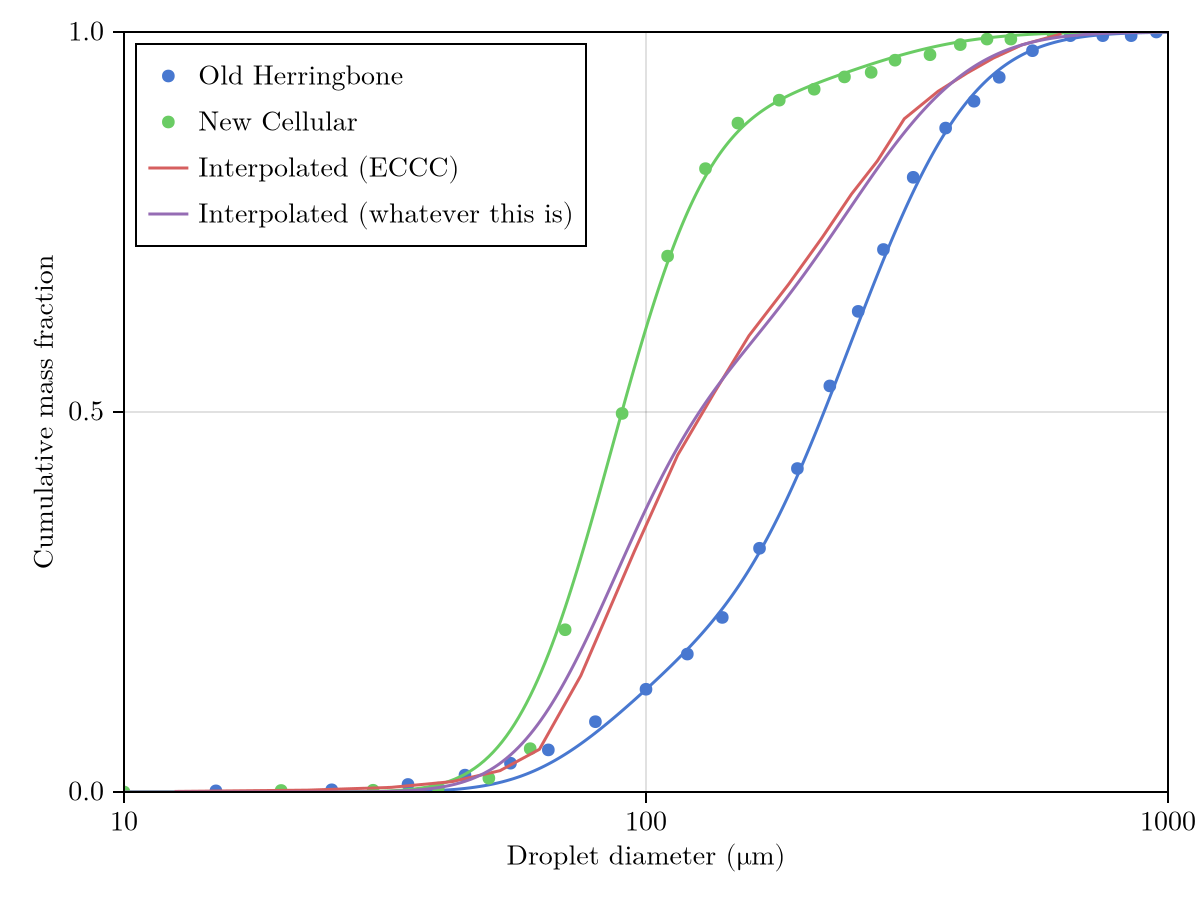

In [24]:
#| echo: false
#| label: fig-comedic-level-of-overfitting
#| fig-cap: "The two measured droplet size distributions, with the combined parametric mixing model."
with_theme(post_theme) do
    f = Figure(figurepadding=0)
    ax = Axis(f[1, 1],
        xlabel = "Droplet diameter (μm)",
        xscale = log10,
        xticks = [10, 100, 1000],
        ylabel = "Cumulative mass fraction",
        limits = ((10,1000),(0,1)),
        #aspect = DataAspect()
    )
    
    ds = 10.0:1.0:1000.0
    scatter!(ax, herringbone.d, herringbone.F, label="Old Herringbone")
    lines!(ax, ds, cdf(MixtureModel(0),ds))
    
    scatter!(ax, cellular.d, cellular.F, label="New Cellular")
    lines!(ax, ds, cdf(MixtureModel(1),ds))

    lines!(ax, ECCC.d, ECCC.F, label="Interpolated (ECCC)")
    lines!(ax, ds, cdf(MixtureModel(0.5),ds), label="Interpolated (whatever this is)")
    axislegend(position=:lt)
    f
end

A good question to ask at this point is whether any of this is justified.

No.

Probably not.

Absent any compelling reason to believe these distributions *should* be considered mixtures, this is really an exercise in over-fitting. It is all too easy to justify to oneself that the assumptions that went into a data analysis are reasonable after looking at how nicely the curves go through the data points.

A Model of Cooling Tower Plumes
-------------------------------

Consider a simple model of a cooling tower ([@fig-cooling-tower-model-diagram]) where the generation of droplets occurs in the tower, creating a mist with a log-normal droplet size distribution, and droplets from that mist are then removed by mist eliminators. For simplicity let's assume the mist eliminators remove droplets according to some efficiency curve $\eta(d)$ but otherwise do not change the underlying distribution.

::: {#fig-cooling-tower-model-diagram}

![](cooling-tower-mist-eliminator-model.png)

A simple model of a cooling tower plume in which a mist is generated and then droplets are removed according to some efficiency curve.
:::

A simple model of removal efficiency is[^efficiency]

$$ \eta \left( d \right) = { 1 \over {1 + \left(d_c \over d\right)^2} } $$

Where $d_c$ is some cut diameter.

[^efficiency]: A typical mist eliminator curve is given by

    $$ \eta = { \mathrm{Stk} \over {\mathrm{Stk} + C} } $$

    Where $\mathrm{Stk}$ is the [Stokes number](https://en.wikipedia.org/wiki/Stokes_number) and $C$ is some constant. Since $\mathrm{Stk} \propto d^2$

    $$ \eta = { d^2 \over {d^2 + \mathrm{const} } } $$

    When $d = d_c$, $\eta = 0.5$, by definition

    $$ 0.5 = { d_c^2 \over {d_c^2 + \mathrm{const} } } $$

    re-arranging we find

    $$ \mathrm{const} = d_c^2 $$

    giving our final model of

    $$ \eta = {d^2 \over {d^2 + d_c^2} } = {1 \over { 1 + \left(d_c \over d\right)^2 } } $$

In [25]:
#| output: false
η(d; dc) = (1 + (dc/d)^2)^-1

η (generic function with 1 method)

The distribution for droplets leaving the tower is then

$$ f(d) = K \left(1 - \eta\left( d \right) \right) \mathscr{f}_{LN} \left( d \right) $$

Where $K$ is some normalization constant and $\mathscr{f}_{LN}(x)$ is the pdf of the log-normal distribution

In [26]:
#| output: false
f(d; LN, dc, K) = K*(1-η(d; dc=dc))*pdf(LN,d)

f (generic function with 1 method)

The normalization constant will have to be calculated numerically, which suggests that building a data structure for the cooling tower would be worthwhile.

In [27]:
#| output: false
struct CoolingTower{D,F}
    LN::D
    dc::F
    K::F
end

Initializing a `CoolingTower` then calculates the normalization constant

In [28]:
using QuadGK: quadgk

In [29]:
#| output: false
function CoolingTower(LN,dc)
    I, err = quadgk( x -> f(x; LN=LN, dc=dc, K=1), 0, Inf)
    return CoolingTower(LN,promote(dc,(1/I))...)
end

CoolingTower

Adding a method for the cdf, calculated by numerically integrating the pdf.

In [30]:
#| output: false
import Distributions.cdf

function cdf(ct::CoolingTower, x::Real)
    I, err = quadgk( t -> f(t; LN=ct.LN, dc=ct.dc, K=ct.K), 0, x)
    return I
end

cdf(ct::CoolingTower, v::AbstractArray{<:Real}) = [ cdf(ct,x) for x in v ]

cdf (generic function with 87 methods)

This is a simple model of a cooling tower but it appears to replicate, at least qualitatively, what we see with the two known datasets. In [@fig-ct-model] the log normal fit to the Old Herringbone data is used as a proxy for a cooling tower with no mist eliminators and then a mist eliminator with a cut diameter of 25&mu;m is applied. The resulting curve is not strictly log-normal, but is extremely well approximated by one.

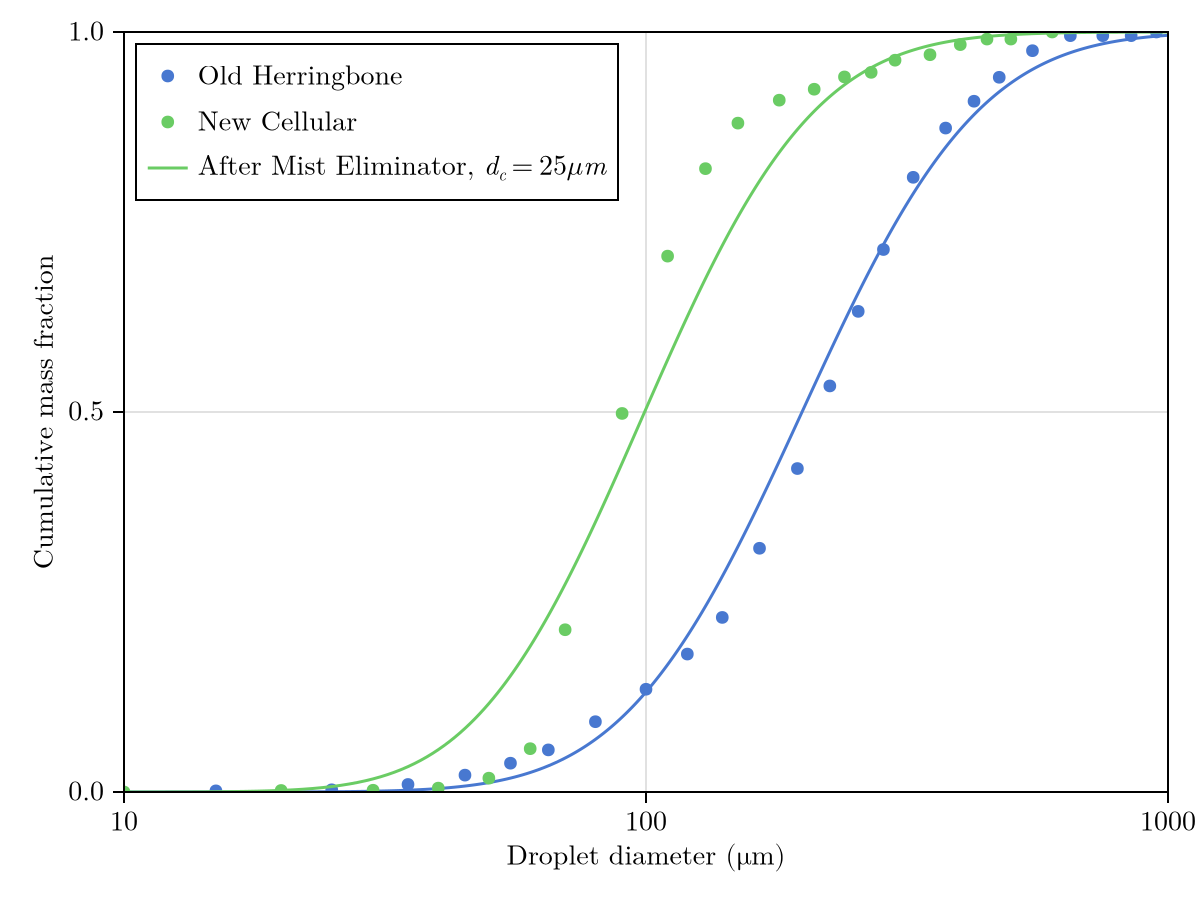

In [31]:
#| echo: false
#| label: fig-ct-model
#| fig-cap: "A cooling tower model showing the Old Herringbone distribution and then that distribution after applying a mist eliminator with cut diameter of 25μm."
with_theme(post_theme) do
    f = Figure(figurepadding=0)
    ax = Axis(f[1, 1],
        xlabel = "Droplet diameter (μm)",
        xscale = log10,
        xticks = [10, 100, 1000],
        ylabel = "Cumulative mass fraction",
        limits = ((10,1000),(0,1)),
        #aspect = DataAspect()
    )
    
    ds = 10.0:1.0:1000.0
    hb = LogNormal(μh,σh)
    scatter!(ax, herringbone.d, herringbone.F, label="Old Herringbone")
    lines!(ax, ds, cdf(hb, ds),)
    
    ct = CoolingTower(hb,25)
    scatter!(ax, cellular.d, cellular.F, label="New Cellular")
    lines!(ax, ds, cdf(ct, ds), label=L"After Mist Eliminator, $d_c = 25\mu m$")

    axislegend(position=:lt)
    f
end

A parameter we would want to know for a mist eliminator is how it effects the overall drift rate for the cooling tower. Suppose the bare tower, with no eliminators, has a drift rate $W$. The new drift rate $W_{e}$ is given by

$$ W_e = \left( 1 - \eta_T \right) W $$

where $\eta_T$ is the total fraction of water removed from the mist entering the mist eliminators and is equal to

$$ \eta_T = \int_0^\infty \eta(x) \mathscr{f}_{LN}(x) dx $$

In [32]:
#| output: false
η_T, err = quadgk( x -> η(x; dc=25)*pdf(LogNormal(μh,σh),x), 0, Inf)

(0.9699870139371453, 3.6259446918626168e-9)

In [33]:
#| echo: false
@handcalcs begin
    η_T; "total removal efficiency";
    W = 0.01 ; "initial drift rate, percent";
    Wₑ = (1 - η_T)*W; "final drift rate, percent"
end precision=5 len=:long h_env="align"

L"\begin{align}
\eta_{T} &= 0.96999\;\text{  }(\text{total removal efficiency})
\\[10pt]
W &= 0.01\;\text{  }(\text{initial drift rate, percent})
\\[10pt]
W_e &= \left( 1 - \eta_{T} \right) \cdot W
\\[10pt]
&= \left( 1 - 0.96999 \right) \cdot 0.01
\\[10pt]
&= 0.0003\;\text{  }(\text{final drift rate, percent})
\end{align}"

In this case I picked the simplest removal efficiency curve to have a nice, easy to reason about, model that did not require calculating a bunch of extra parameters. It is clear from the data that this does not lead to as sharp of a distribution as we see with the New Cellular data. One could probably extend this by using a more flexible model of mist eliminator efficiency, a common one I see looks like this

$$ \eta(d) = {1 \over {1 + \exp \left( - \lambda \left( d - d_{ref} \right) \right) } } $$

where $\lambda$ and $d_{ref}$ are empirical model parameters. Finding the set of efficiency curve parameters to best fit New Cellular data from the Old Herringbone could then also be done (it is just another optimization problem) but I think that is very getting into the weeds. I mostly wanted to show that one can qualitatively explain the differences between the two cooling tower data sets using a simple model of removal efficiency.

This model also shows that it is not unreasonable, if one does not want to go to the effort of building a model of mist eliminators, to estimate the final droplet size distribution as log-normal where the parameters $\mu$ and $\sigma$ are functions of operating parameters. Passing a log-normal mist through a mist eliminator produces one that is well approximated by a log-normal but with the $\mu$ shifted to smaller diameter droplets, and $\sigma$ shifted to create a steeper curve.

Final Thoughts and Recommendations
----------------------------------

In the above noodling around I presented three broad approaches that could be reasonable ways of interpolating between known droplet size distributions. Straight interpolation between the cumulative distribution functions, fitting a log-normal and interpolating the parameters, and finally fitting a more complex model and interpolating on the model parameters there. My personal preference would be to do the simple log-normal fit and interpolate on the parameters for that. Generating the log-normal fit only has to be done once and the final interpolation is much simpler to package into a calculation tool, such as a spreadsheet, or incorporated into the various database tools that automatically generate emissions inventories for facilities. The code to implement it requires 6 parameters and the error function to be available. Unlike the original ECCC tool which must keep around the full tables of data to do any of the calculations. You may argue that the log-normal fits are not very good, but I think in the context of these kinds of emissions calculations -- which are really only good to 1 or 2 significant figures -- it's probably fine.

The way the ECCC tool is constructed strikes me as missing an obvious feature: it does the interpolation described above to generate an additional table of droplet sizes then asks the user to manually select which of the three tables best fits their cooling tower: the old herringbone, new cellular, or the interpolated value. It makes more sense to me to simply ask the user to enter the drift rate for their tower and interpolate to *that* drift rate. If it is valid to interpolate to exactly the mid-point between the two known curves, it is just as valid to interpolate to anywhere else in between.